Cartpole - среда для обучения и демонстрации работы методов обучения с подкреплением, в которой агент управляет тележкой, чтобы удерживать вертикально установленный стержень. Состояние системы задаётся вектором из 4 величин: позиция тележки, скорость, угол стержня, угловая скорость стержня. Пространство действий - возможные действия, предпринимаемые согласно методу обучения агента: 0 - сдвинуть тележку влево, 1 - вправо. Награда за каждый шаг равна +1, если тележка не упала, и эпизод продолжается. Награда дается за поддержание баланса стержня и за удержание тележки в пределах заданного положения и скорости. Эпизод завершается, если одно из следующих условий выполняется: угол наклоны стержня больше 12 град., положение тележки выходит за пределы разрешенной зоны(2.4 метра влево или вправо), угловая скорость или угол стержня слишком большие. Существует максимальное число шагов, которые может сделать алгоритм: 500. Если за 500 шагов эпизод не завершился, считается, что алгоритм справился с задачей.

Описание алгоритмов.
Случайный поиск - простейший алгоритм оптимизации, который не использует никаких сведений об особенностях задачи или о структуре функции вознаграждения. Он просто случайным образом генерирует множества параметров и выбирает те, которые дают лучшие результаты. Принцип работы: задаётся некоторое количество итераций, на каждой итерации генерируются случайные параметры, политика с этими параметрами оценивается в среде. В конце выбирается лучшие параметры.

Восхождение на вершину - похоже на жадное локальное улучшение. Начинаем с некоторой политики, затем пробуем соседние варианты параметров, добавляя шум, и принимаем улучшения, если они дают более высокую награду.

Градиент стратегии — метод обучения параметризованной стохастической политики, который обновляет параметры в направлении роста ожидаемого вознаграждения, используя оценку градиента через log‑вероятности действий (например, алгоритм REINFORCE).

Mountain car тоже является средой наподобие CartPole. В этой среде агент управляет тележкой, которая должна достигнуть вершины холма. Чтобы это сделать, он должен использовать физику качания: тележка должна разогнаться, чтобы преодолеть холм, который она не может сразу преодолеть. Состояние средя описывается двумя параметрами: позиция и скорость тележки. Алгоритм может совершать 3 действия: 0 - двигать тележку влево, 1 - не двигать тележку, 2 - двигать вправо. Агент получает -1 за каждый шаг. Таким образом, задача обученного агента - максимизировать награду, максимально приблизившись к нулю. Эпизод завершается, если тележка достигнет вершины или агент достигнет максимального количества шагов в 200 итераций.

Для того, чтобы максимизировать награду в среде mountain car был реализован алгоритм восхождения на вершину, который сильнее увеличивает шум, если некоторое время не наблюдалось прогресса, т.к. алгоритм восхождения склонен иногда застревать на локальных максимумах

Эпизод 1/500, Лучший результат: 9.40
Эпизод 2/500, Лучший результат: 135.30
Эпизод 3/500, Лучший результат: 135.30
Эпизод 4/500, Лучший результат: 135.30
Эпизод 5/500, Лучший результат: 135.30
Эпизод 6/500, Лучший результат: 135.30
Эпизод 7/500, Лучший результат: 135.30
Эпизод 8/500, Лучший результат: 135.30
Эпизод 9/500, Лучший результат: 135.30
Эпизод 10/500, Лучший результат: 135.30
Эпизод 11/500, Лучший результат: 135.30
Эпизод 12/500, Лучший результат: 135.30
Эпизод 13/500, Лучший результат: 135.30
Эпизод 14/500, Лучший результат: 135.30
Эпизод 15/500, Лучший результат: 135.30
Эпизод 16/500, Лучший результат: 135.30
Эпизод 17/500, Лучший результат: 135.30
Эпизод 18/500, Лучший результат: 135.30
Эпизод 19/500, Лучший результат: 135.30
Эпизод 20/500, Лучший результат: 135.30
Эпизод 21/500, Лучший результат: 135.30
Эпизод 22/500, Лучший результат: 135.30
Эпизод 23/500, Лучший результат: 135.30
Эпизод 24/500, Лучший результат: 135.30
Эпизод 25/500, Лучший результат: 135.30
Эпизод 26/5

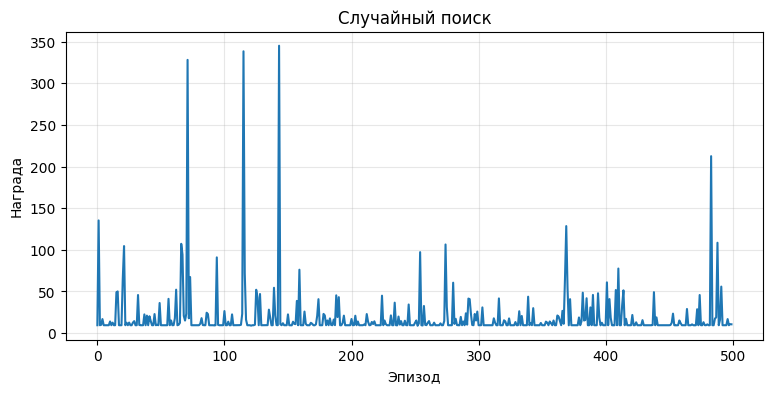

In [29]:
import io
import time
from PIL import Image
from IPython.display import Image as IPyImage, display
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1")


obs_dim = env.observation_space.shape[0]  # размерность наблюдений
n_actions = env.action_space.n  # число возможных действий

rng = np.random.default_rng(seed=42)

def linear_policy_action(obs, W, b): # линейная политика
    logits = W @ obs + b
    return int(np.argmax(logits))

def eval_linear_policy(env, W, b, n_episodes=1):
    enve = gym.make(env)
    total_reward = 0.0
    for i in range(n_episodes):
        obs, _ = enve.reset(seed=123 + i)
        done = False
        ep_reward = 0.0
        steps = 0
        while not done:
            action = linear_policy_action(np.asarray(obs, dtype=np.float32), W, b)
            obs, reward, terminated, truncated, _ = enve.step(action)
            done = terminated or truncated
            ep_reward += reward
            steps += 1
        total_reward += ep_reward
    enve.close()
    return total_reward / n_episodes

def initialize_params(scale=1.0):
    W = rng.normal(loc=0.0, scale=scale, size=(n_actions, obs_dim))
    b = rng.normal(loc=0.0, scale=scale, size=(n_actions,))
    return W, b

def random_search(env, episodes=500, steps=10, scale=1.0, visible_result=True):
    best_W, best_b = initialize_params(scale=scale)
    best_score = -float("inf")
    rewards = []

    for ep in range(episodes):
        W, b = initialize_params()
        score = eval_linear_policy(env, W, b, n_episodes=steps)
        rewards.append(score)

        if score > best_score:
            best_score = score
            best_W, best_b = W, b
        if visible_result:
            print(f"Эпизод {ep + 1}/{episodes}, Лучший результат: {best_score:.2f}")
    print("Результат:", best_score)

    return best_W, best_b, best_score, rewards

best_W, best_b, best_score, rewards = random_search("CartPole-v1", episodes=500, steps=10, scale=1.0)


print(f"\nЛучшая политика случайного поиска найдена с результатом {best_score:.2f} в среднем")

def build_plot(rewards, title):
    plt.figure(figsize=(9,4))
    plt.plot(rewards)
    plt.title(title)
    plt.xlabel("Эпизод")
    plt.ylabel("Награда")
    plt.grid(True, alpha=0.3)
    plt.show()

build_plot(rewards, "Случайный поиск")


365.0


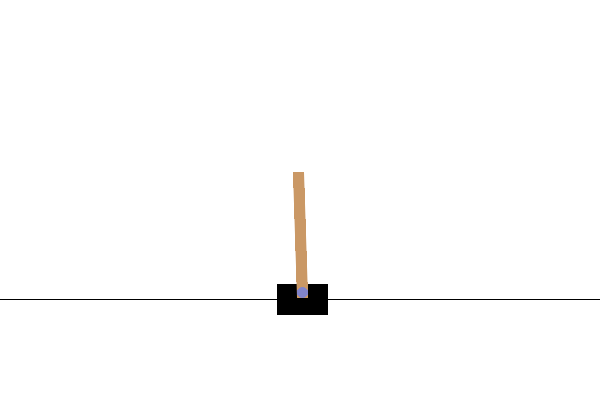

In [30]:
def rollout_frames_cartpole(env_id, W, b, seed=123, max_steps=500):
    env = gym.make(env_id, render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)

    frames = []
    done = False
    steps = 0
    total_reward = 0.0
    rew = 0
    while not done and steps < max_steps:
        frames.append(env.render())
        a = linear_policy_action(np.asarray(obs, dtype=np.float32), W, b)
        obs, r, terminated, truncated, _ = env.step(a)
        rew += r
        done = terminated or truncated
        total_reward += float(r)
        steps += 1
    print(total_reward)
    env.close()
    return frames, total_reward

frames, demo_reward = rollout_frames_cartpole("CartPole-v1", best_W, best_b)
len(frames), demo_reward

def frames_to_gif_bytes(frames, fps=60):
    imgs = [Image.fromarray(f) for f in frames]
    bio = io.BytesIO()
    imgs[0].save(
        bio,
        format="GIF",
        save_all=True,
        append_images=imgs[1:],
        duration=int(1000 / fps),
        loop=0,
    )
    bio.seek(0)
    return bio.getvalue()

gif_bytes = frames_to_gif_bytes(frames, fps=30)
display(IPyImage(data=gif_bytes))

В качестве гиперпараметров для случайного поиска выберем следующие значения: 500 эпизодов, 10 повторений в каждом эпизоде с новым сидом среды, случайный параметры будут генерироваться солгасно стандартному нормальному закону

Эпизод 1/500, Лучший результат: 9.40
Эпизод 2/500, Лучший результат: 9.40
Эпизод 3/500, Лучший результат: 9.40
Эпизод 4/500, Лучший результат: 9.40
Эпизод 5/500, Лучший результат: 9.40
Эпизод 6/500, Лучший результат: 9.40
Эпизод 7/500, Лучший результат: 9.40
Эпизод 8/500, Лучший результат: 9.40
Эпизод 9/500, Лучший результат: 9.40
Эпизод 10/500, Лучший результат: 9.40
Эпизод 11/500, Лучший результат: 9.40
Эпизод 12/500, Лучший результат: 9.40
Эпизод 13/500, Лучший результат: 9.40
Эпизод 14/500, Лучший результат: 9.40
Эпизод 15/500, Лучший результат: 9.40
Эпизод 16/500, Лучший результат: 9.40
Эпизод 17/500, Лучший результат: 9.40
Эпизод 18/500, Лучший результат: 9.40
Эпизод 19/500, Лучший результат: 9.40
Эпизод 20/500, Лучший результат: 9.40
Эпизод 21/500, Лучший результат: 9.40
Эпизод 22/500, Лучший результат: 9.40
Эпизод 23/500, Лучший результат: 9.40
Эпизод 24/500, Лучший результат: 9.40
Эпизод 25/500, Лучший результат: 9.40
Эпизод 26/500, Лучший результат: 9.40
Эпизод 27/500, Лучший

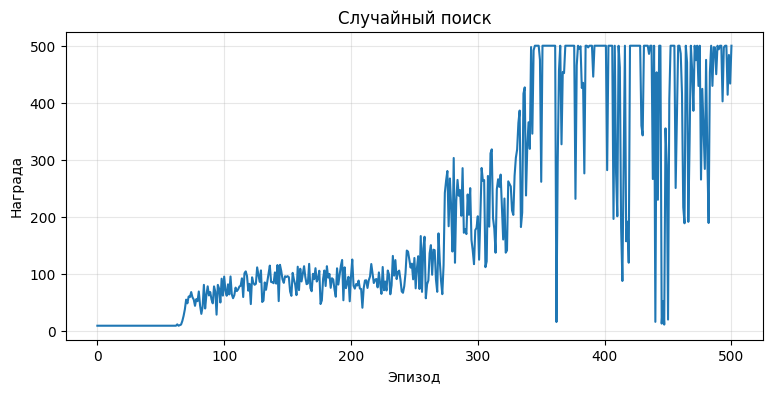

500.0


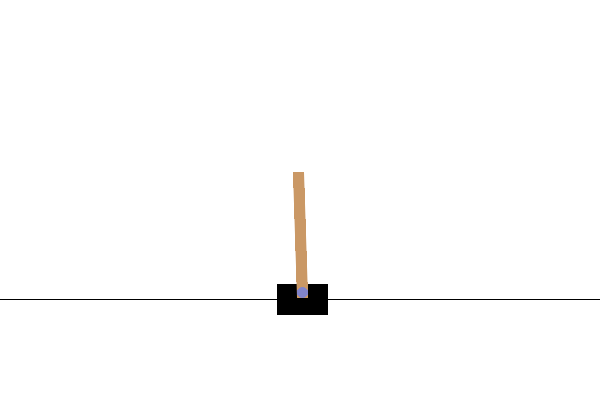

In [ ]:
rng = np.random.default_rng(seed=42)
def hill_climbing(env, episodes=500, noise_std=0.1, init_scale=1.0, visible_result=True, n_episodes=10):

    W = rng.normal(loc=0.0, scale=init_scale, size=(n_actions, obs_dim)).astype(np.float32)
    b = rng.normal(loc=0.0, scale=init_scale, size=(n_actions,)).astype(np.float32)

    best_W = W.copy()
    best_b = b.copy()
    best_score = eval_linear_policy(env, best_W, best_b, n_episodes=n_episodes)

    rewards = [best_score]

    for ep in range(episodes):
        W_try = best_W + rng.normal(0.0, noise_std, size=best_W.shape).astype(np.float32) #добавление шума
        b_try = best_b + rng.normal(0.0, noise_std, size=best_b.shape).astype(np.float32)

        score = eval_linear_policy(env, W_try, b_try, n_episodes=n_episodes)
        rewards.append(score)

        if score >= best_score:
            best_score = score
            best_W, best_b = W_try, b_try
        if visible_result:
            print(f"Эпизод {ep + 1}/{episodes}, Лучший результат: {best_score:.2f}")
    print("Результат:", best_score)
    return best_W, best_b, best_score, rewards

hc_W, hc_b, hc_best_score, hc_rewards = hill_climbing("CartPole-v1", episodes=500, noise_std=0.1, init_scale=1.0)

print(f"\nЛучшая политика восхождения на вершина найдена с результатом: {hc_best_score:.2f}")


build_plot(hc_rewards, "Случайный поиск")
hc_frames, hc_demo_reward = rollout_frames_cartpole("CartPole-v1", hc_W, hc_b, seed=123)
hc_gif_bytes = frames_to_gif_bytes(hc_frames, fps=30)
display(IPyImage(data=hc_gif_bytes))

Выберем гиперпараметры: 500 эпизодов, 10 шагов, стандартное нормальное распределение для начальных параметров, отклонение в 0.1 и мат ожидание в 0 единиц для генерации шума

Эпизод 1/500 | Результат 26
Эпизод 2/500 | Результат 18
Эпизод 3/500 | Результат 36
Эпизод 4/500 | Результат 30
Эпизод 5/500 | Результат 14
Эпизод 6/500 | Результат 12
Эпизод 7/500 | Результат 25
Эпизод 8/500 | Результат 20
Эпизод 9/500 | Результат 12
Эпизод 10/500 | Результат 10
Эпизод 11/500 | Результат 25
Эпизод 12/500 | Результат 20
Эпизод 13/500 | Результат 14
Эпизод 14/500 | Результат 9
Эпизод 15/500 | Результат 23
Эпизод 16/500 | Результат 28
Эпизод 17/500 | Результат 30
Эпизод 18/500 | Результат 9
Эпизод 19/500 | Результат 10
Эпизод 20/500 | Результат 29
Эпизод 21/500 | Результат 16
Эпизод 22/500 | Результат 17
Эпизод 23/500 | Результат 10
Эпизод 24/500 | Результат 16
Эпизод 25/500 | Результат 11
Эпизод 26/500 | Результат 19
Эпизод 27/500 | Результат 21
Эпизод 28/500 | Результат 15
Эпизод 29/500 | Результат 16
Эпизод 30/500 | Результат 15
Эпизод 31/500 | Результат 9
Эпизод 32/500 | Результат 16
Эпизод 33/500 | Результат 21
Эпизод 34/500 | Результат 10
Эпизод 35/500 | Результат 

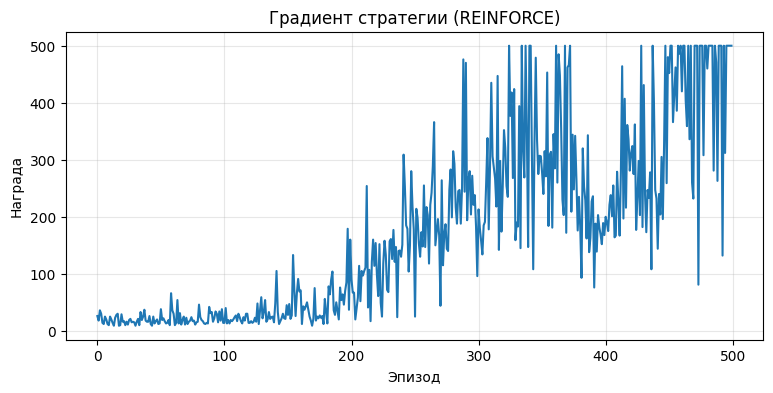

PG demo reward: 500.0


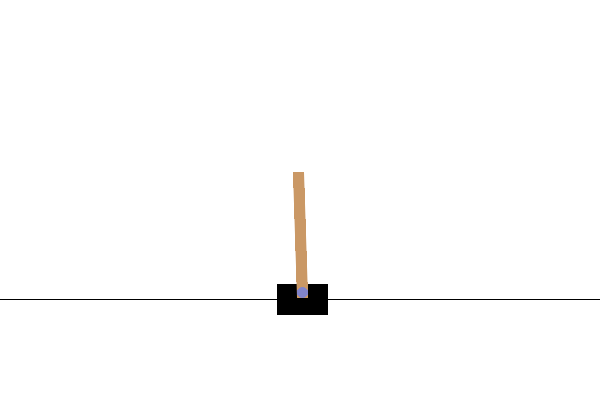

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim


class PGPolicy(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)


def train_policy_gradient(env_id="CartPole-v1", episodes=500, lr=1e-2, gamma=0.99, seed=42, visible_result=True):
    torch.manual_seed(seed)
    np.random.seed(seed)

    env = gym.make(env_id)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    policy = PGPolicy(obs_dim, n_actions, hidden=32)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    rewards_history = []

    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + ep)

        log_probs = []
        ep_rewards = []

        done = False
        while not done:
            obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            logits = policy(obs_t)
            dist = torch.distributions.Categorical(logits=logits)

            action = dist.sample()
            log_prob = dist.log_prob(action)

            obs, r, terminated, truncated, _ = env.step(int(action.item()))
            done = terminated or truncated

            log_probs.append(log_prob)
            ep_rewards.append(float(r))

        rewards_history.append(sum(ep_rewards))

        G = 0.0
        returns = []
        for r in reversed(ep_rewards):
            G = r + gamma * G
            returns.append(G)
        returns.reverse()
        returns_t = torch.tensor(returns, dtype=torch.float32)

        if len(returns) > 1:
            returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

        loss = 0.0
        for lp, Rt in zip(log_probs, returns_t):
            loss = loss + (-lp * Rt)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()

        last = rewards_history[-1]
        if visible_result:
            print(f"Эпизод {ep+1}/{episodes} | Результат {last:.0f}")

    print('Лучший результат: ', max(rewards_history))
    env.close()
    return policy, rewards_history

pg_policy, pg_rewards = train_policy_gradient(
    env_id="CartPole-v1",
    episodes=500,
    lr=3e-3,
    gamma=0.99,
    seed=42
)


build_plot(pg_rewards, "Градиент стратегии (REINFORCE)")

def rollout_frames_cartpole_pg(policy, seed=123, max_steps=500):
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)

    frames = []
    done = False
    steps = 0
    total_reward = 0.0

    while not done and steps < max_steps:
        frames.append(env.render())

        with torch.no_grad():
            obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            logits = policy(obs_t)
            action = int(torch.argmax(logits, dim=1).item())

        obs, r, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += float(r)
        steps += 1

    env.close()
    return frames, total_reward

pg_frames, pg_demo_reward = rollout_frames_cartpole_pg(pg_policy, seed=123)
print("PG demo reward:", pg_demo_reward)
pg_gif_bytes = frames_to_gif_bytes(pg_frames, fps=30)
display(IPyImage(data=pg_gif_bytes))

500 эпизодов, скорость обучения 0.003, коэффициент дисконтирования в 0.99

Результат: 281.0
Время работы случайного поиска с параметрами:
 эпизод: 100
повторений:1. 0.1411



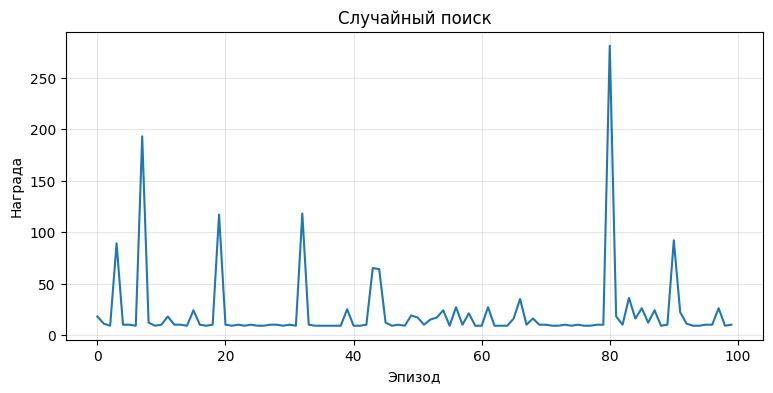

Результат: 223.0
Время работы случайного поиска с параметрами:
 эпизод: 100
повторений:5. 0.3366



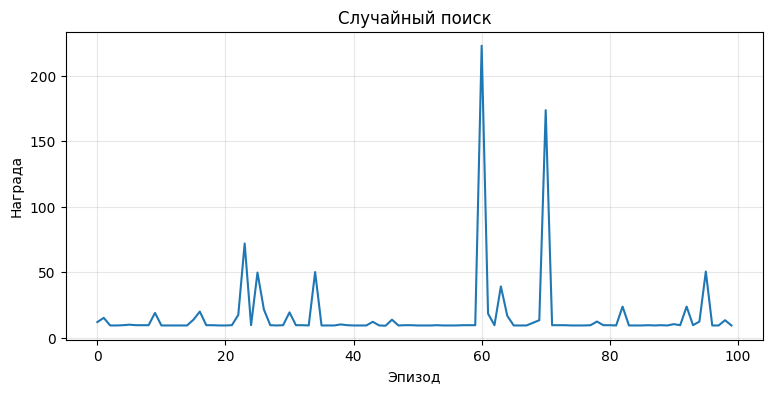

Результат: 183.1
Время работы случайного поиска с параметрами:
 эпизод: 100
повторений:10. 0.5888



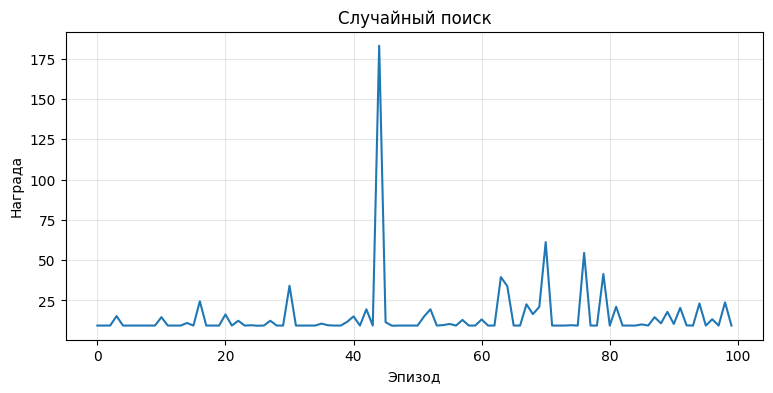

Результат: 316.0
Время работы случайного поиска с параметрами:
 эпизод: 300
повторений:1. 0.3961



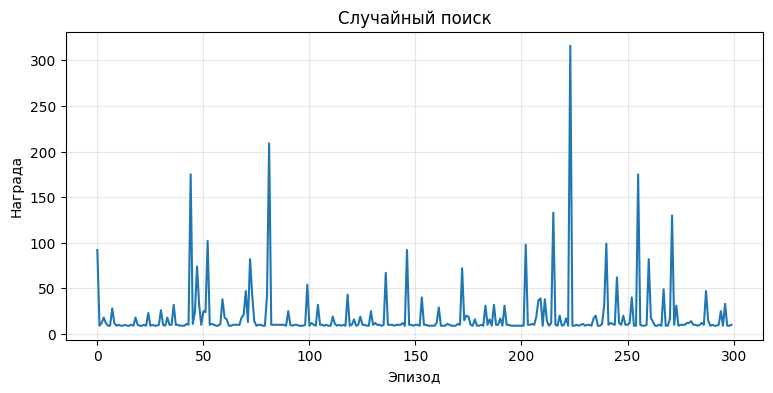

Результат: 287.8
Время работы случайного поиска с параметрами:
 эпизод: 300
повторений:5. 1.0616



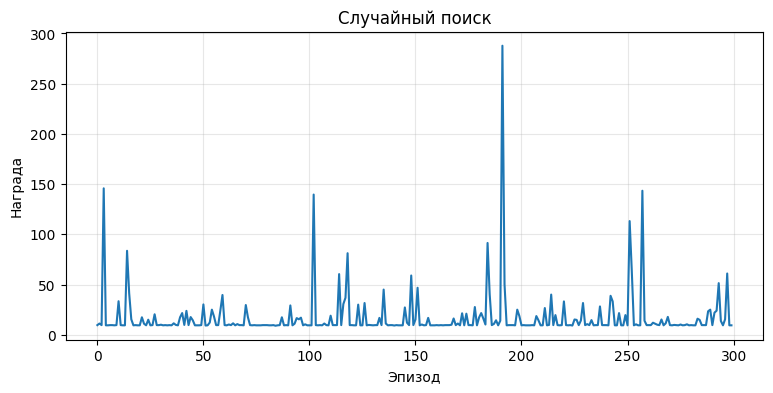

Результат: 122.7
Время работы случайного поиска с параметрами:
 эпизод: 300
повторений:10. 1.8489



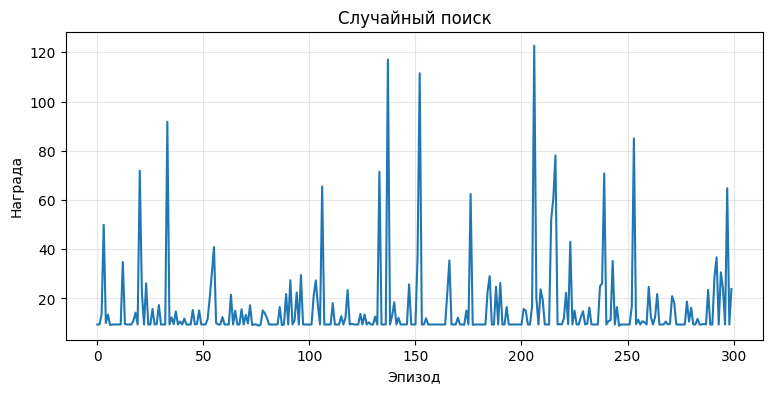

Результат: 500.0
Время работы случайного поиска с параметрами:
 эпизод: 500
повторений:1. 0.6692



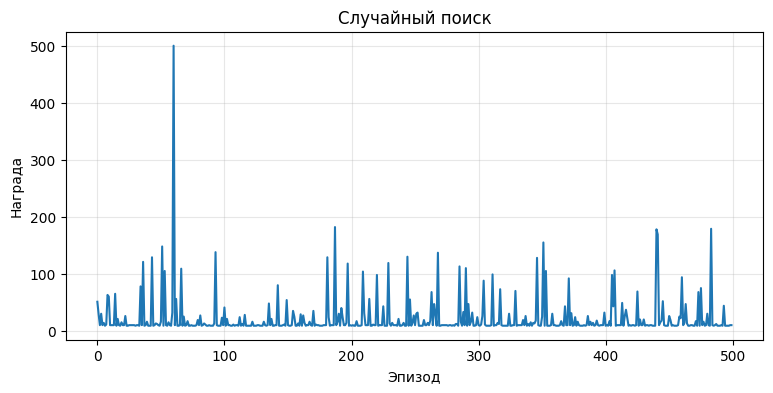

Результат: 392.8
Время работы случайного поиска с параметрами:
 эпизод: 500
повторений:5. 2.0530



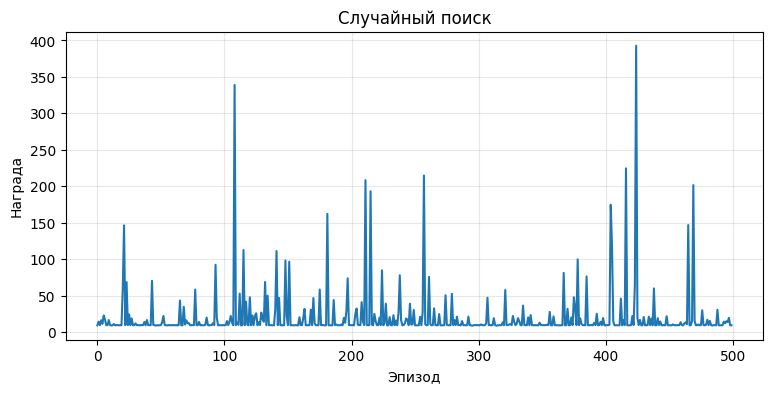

Результат: 500.0
Время работы случайного поиска с параметрами:
 эпизод: 500
повторений:10. 3.6455



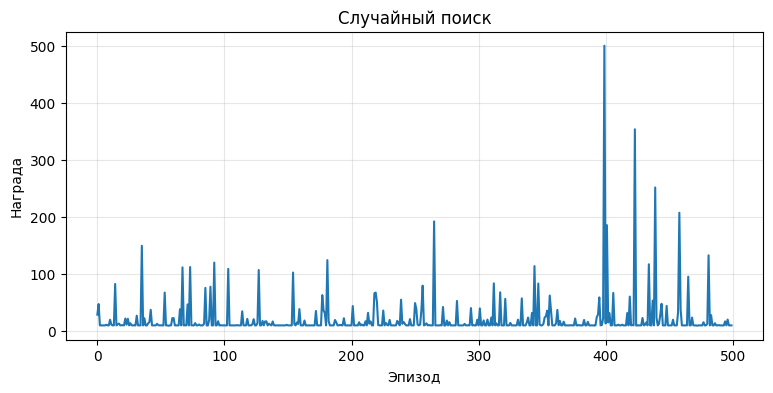

Результат: 500.0
Время работы случайного поиска с параметрами:
 эпизод: 1000
повторений:1. 1.3798



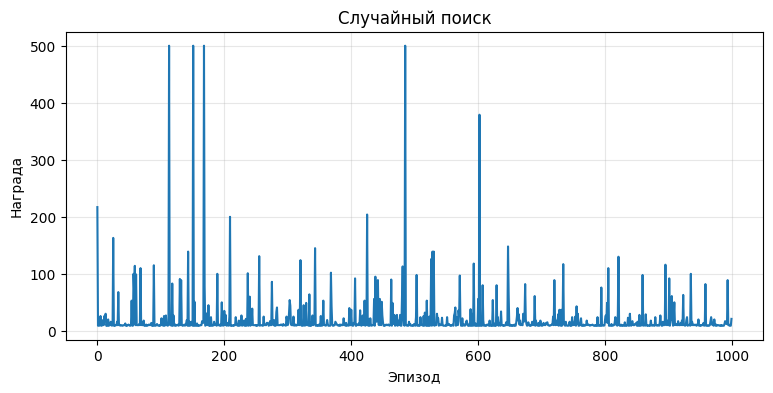

Результат: 500.0
Время работы случайного поиска с параметрами:
 эпизод: 1000
повторений:5. 3.8469



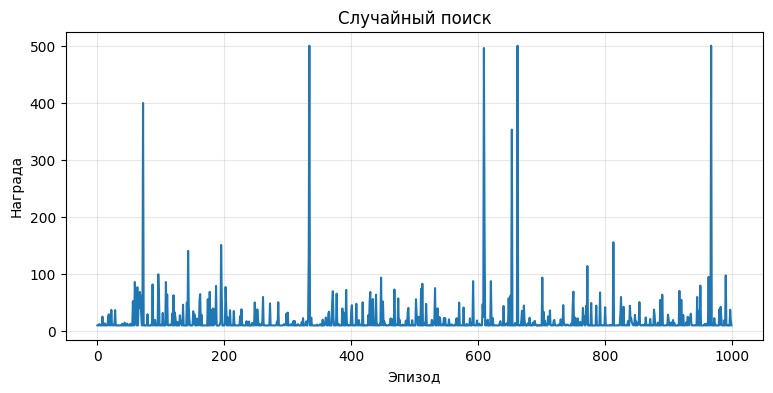

Результат: 500.0
Время работы случайного поиска с параметрами:
 эпизод: 1000
повторений:10. 7.5518



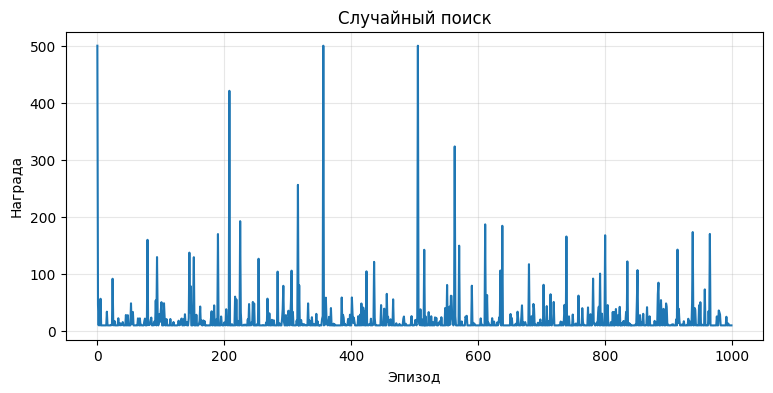

In [26]:
for EPISODES in [100, 300, 500, 1000]:
    for STEPS in [1, 5, 10]:
        start_time = time.time()
        best_W, best_b, best_score, rewards = random_search("CartPole-v1", episodes=EPISODES, steps=STEPS, scale=1.0, visible_result=False)
        end_time = time.time()
        print(f"Время работы случайного поиска с параметрами:\n эпизод: {EPISODES}\nповторений:{STEPS}. {end_time - start_time:.4f}\n")
        build_plot(rewards, "Случайный поиск")

По результатам случайного поиска, награды на графике выглядят как редкие случайные пики на фоне низких значений, даже при увеличении числа эпизодов до 1000 улучшение носит случайный характер. Отсутствует выраденная линия тренда роста, то есть обучение не накапливает значения. Стабильная успешность достигается только про более чем 500 эпизодах, однако алгоритм нестабилен, т.к. результат зависит от удачи. Временные рамки в проведенных тестах: от 0.14 до 7.79 секунд. Не сходится, т.к. нет тренда улучшения.

Результат: 9.4
Время работы восхождения с параметрами:
 эпизод: 100\отклонение:0.1. 0.4093



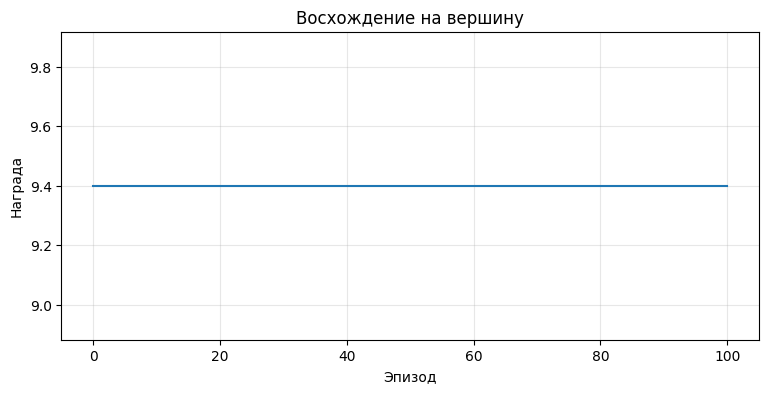

Результат: 9.4
Время работы восхождения с параметрами:
 эпизод: 100\отклонение:0.5. 0.4223



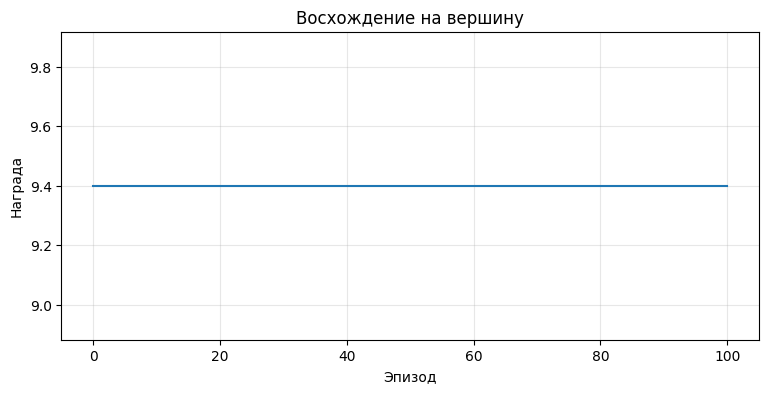

Результат: 500.0
Время работы восхождения с параметрами:
 эпизод: 100\отклонение:1.0. 3.0836



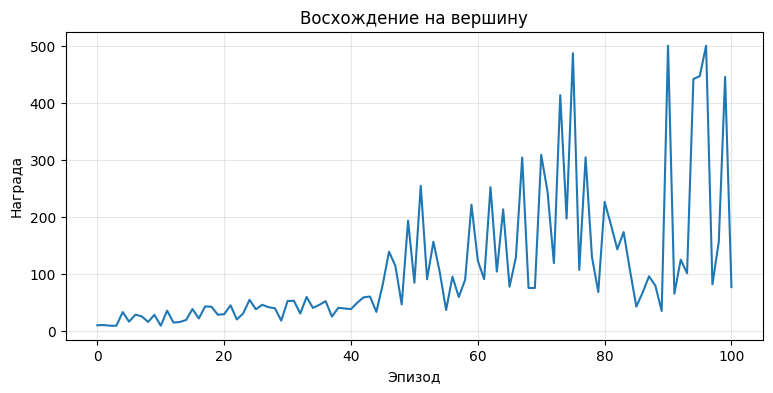

Результат: 138.0
Время работы восхождения с параметрами:
 эпизод: 300\отклонение:0.1. 3.8435



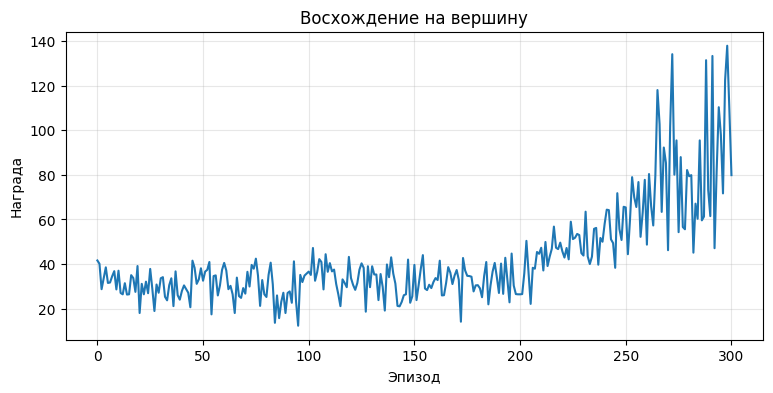

Результат: 500.0
Время работы восхождения с параметрами:
 эпизод: 300\отклонение:0.5. 23.1633



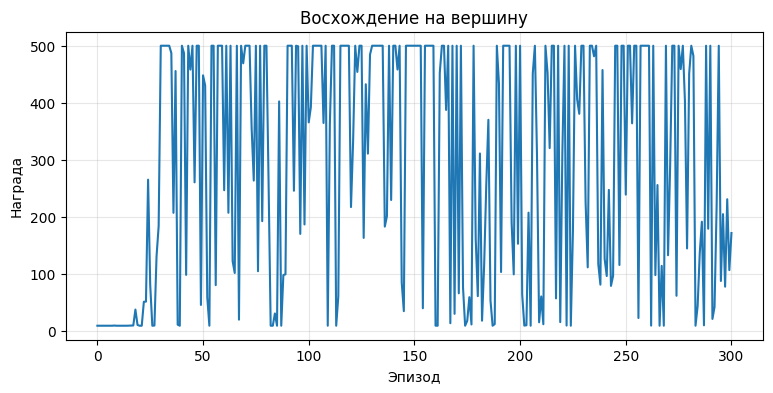

Результат: 500.0
Время работы восхождения с параметрами:
 эпизод: 300\отклонение:1.0. 22.7863



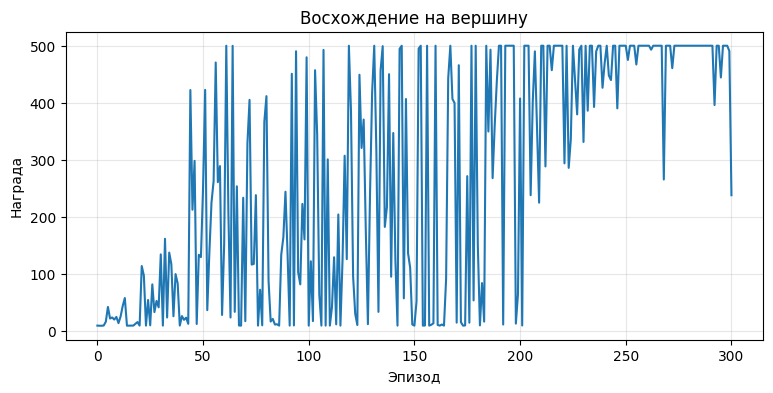

Результат: 500.0
Время работы восхождения с параметрами:
 эпизод: 500\отклонение:0.1. 48.3005



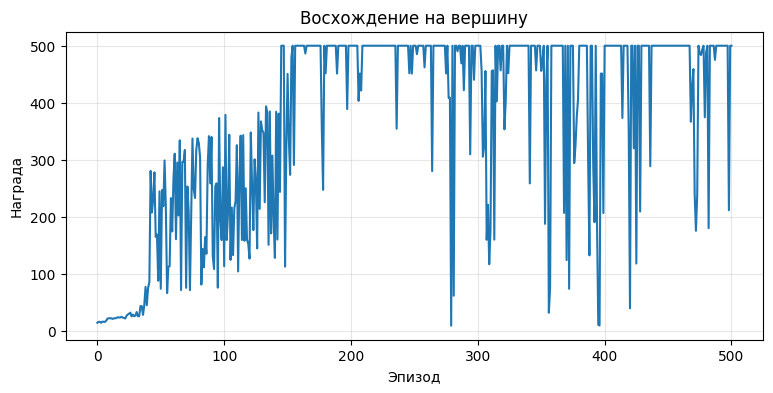

Результат: 500.0
Время работы восхождения с параметрами:
 эпизод: 500\отклонение:0.5. 45.2980



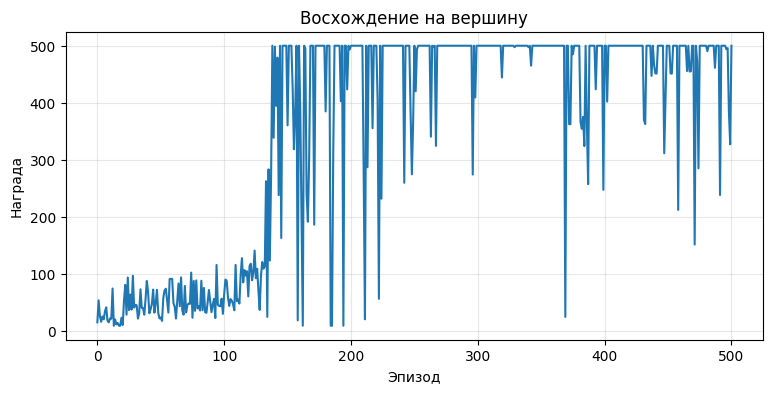

Результат: 500.0
Время работы восхождения с параметрами:
 эпизод: 500\отклонение:1.0. 30.2408



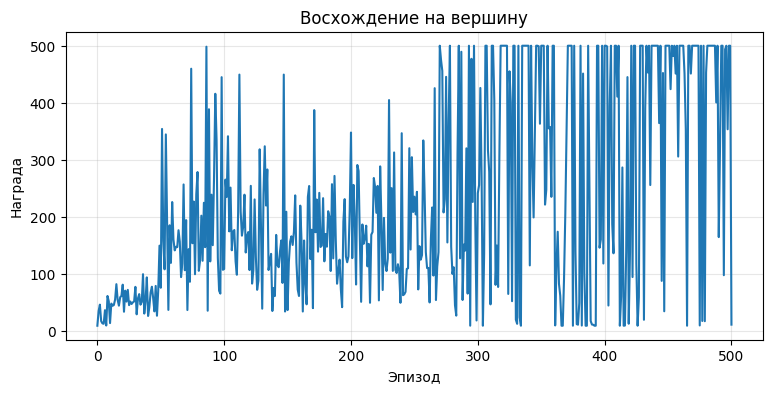

Результат: 500.0
Время работы восхождения с параметрами:
 эпизод: 1000\отклонение:0.1. 122.7636



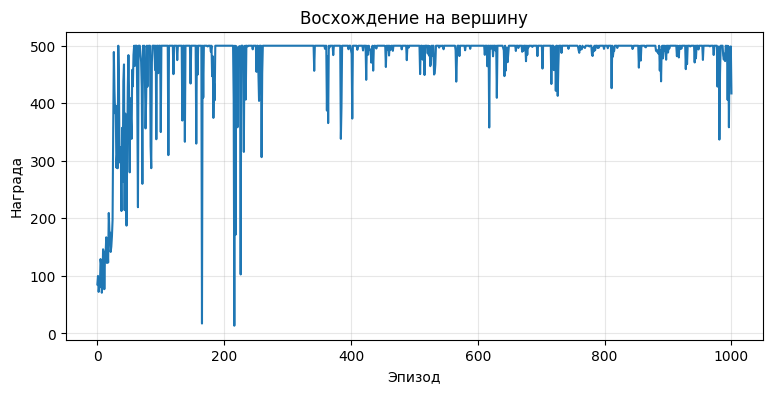

Результат: 9.8
Время работы восхождения с параметрами:
 эпизод: 1000\отклонение:0.5. 4.0469



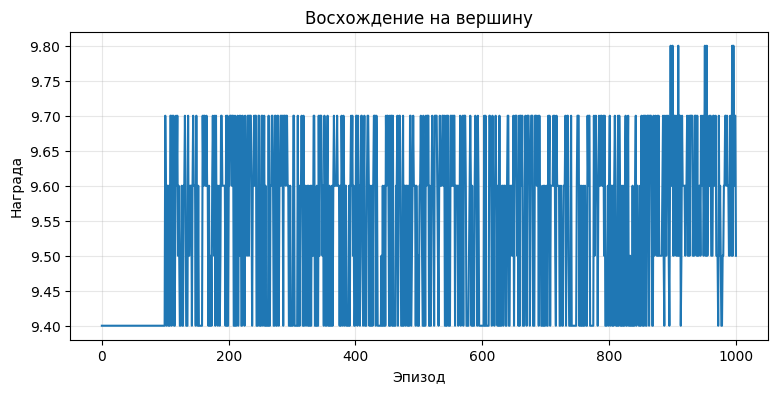

Результат: 500.0
Время работы восхождения с параметрами:
 эпизод: 1000\отклонение:1.0. 117.7005



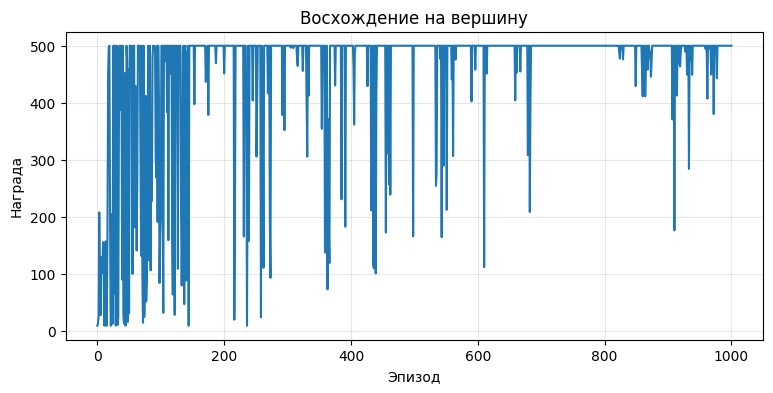

In [33]:
for EPISODES in [100, 300, 500, 1000]:
    for STD in [0.1, 0.5, 1.0]:
        start_time = time.time()
        hc_W, hc_b, hc_best_score, hc_rewards = hill_climbing("CartPole-v1", episodes=EPISODES, noise_std=STD, init_scale=1.0, visible_result=False)
        end_time = time.time()
        print(f"Время работы восхождения с параметрами:\n эпизод: {EPISODES}\отклонение:{STD}. {end_time - start_time:.4f}\n")
        build_plot(hc_rewards, "Восхождение на вершину")

По результатам восхождения на вершину заметен постепенный рост награды, уже при 100 эпизодах есть случай, когда алгоритм достигает максимум нагрыды. Однако, так же видно, что при некоторых входных данных алгоритм может застревать на локальном максимуме и выдавать плохой результат(например, при 1000 эпизодах и отклонении в 0.5). Временные затраты: от 0.4 до 122 секунд. На работу метода влияет и отклонения для шума, и количество эпизодов(при малых значениях эпизодов).

Лучший результат:  26.0
Время работы градиента с параметрами:
 эпизод: 100\скорость:0.3. 1.0414



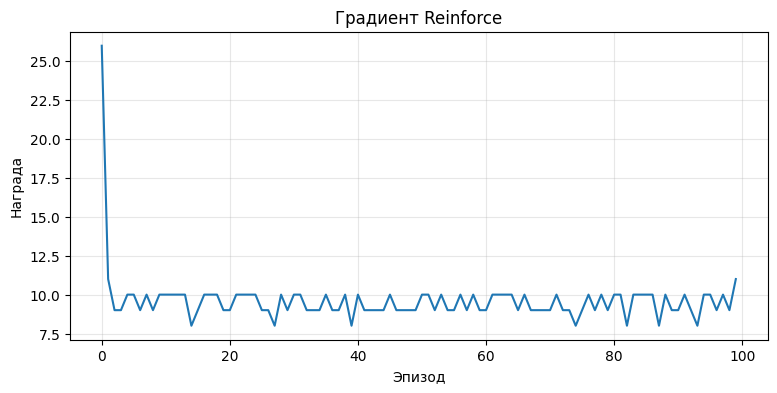

Лучший результат:  164.0
Время работы градиента с параметрами:
 эпизод: 100\скорость:0.03. 5.1732



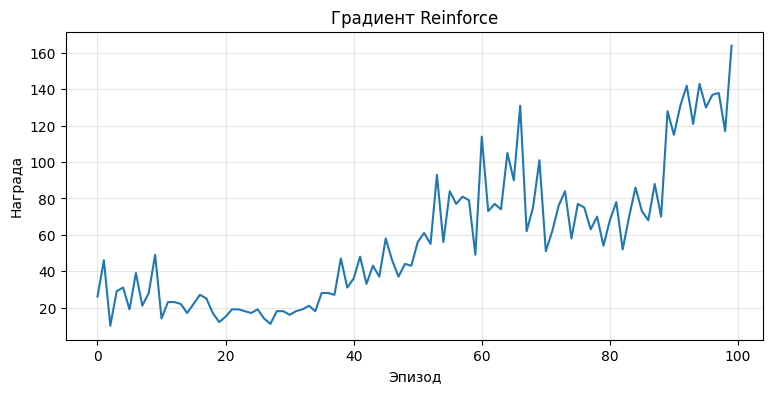

Лучший результат:  66.0
Время работы градиента с параметрами:
 эпизод: 100\скорость:0.003. 1.9993



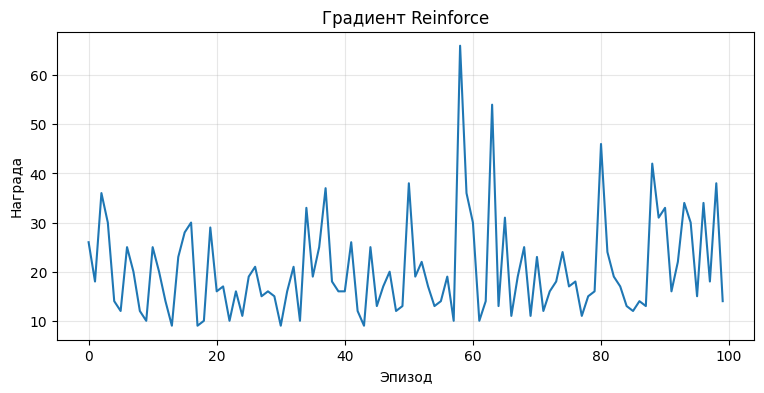

Лучший результат:  26.0
Время работы градиента с параметрами:
 эпизод: 300\скорость:0.3. 2.9805



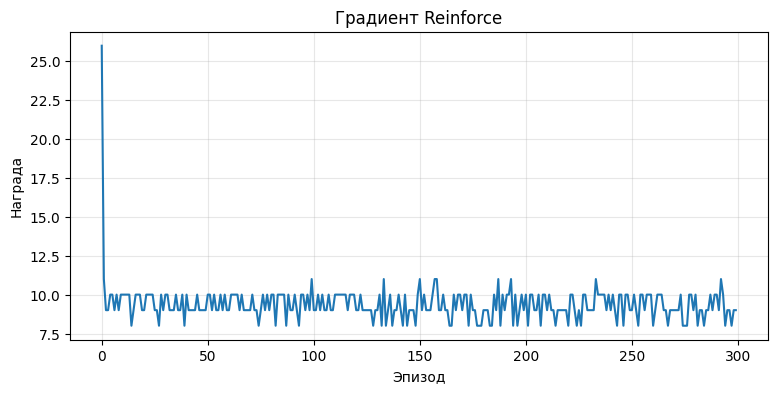

Лучший результат:  500.0
Время работы градиента с параметрами:
 эпизод: 300\скорость:0.03. 66.0455



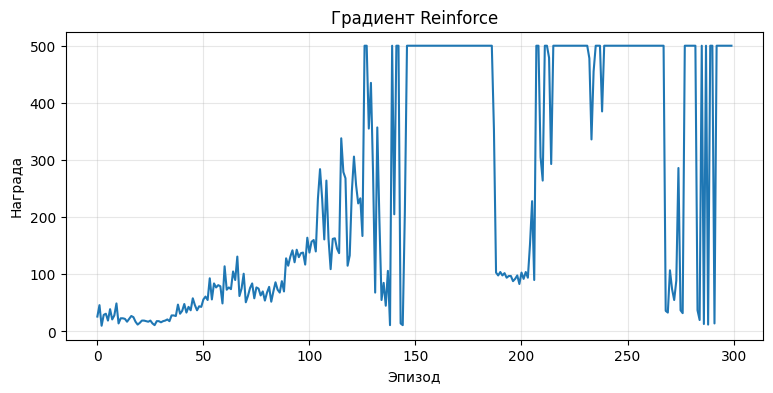

Лучший результат:  476.0
Время работы градиента с параметрами:
 эпизод: 300\скорость:0.003. 22.7584



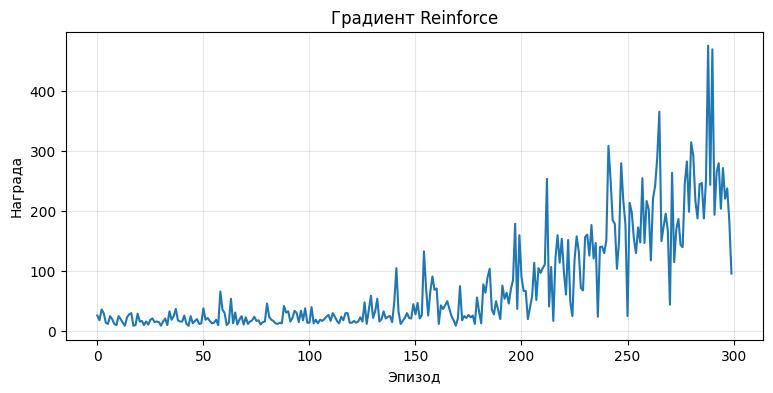

Лучший результат:  26.0
Время работы градиента с параметрами:
 эпизод: 500\скорость:0.3. 6.9912



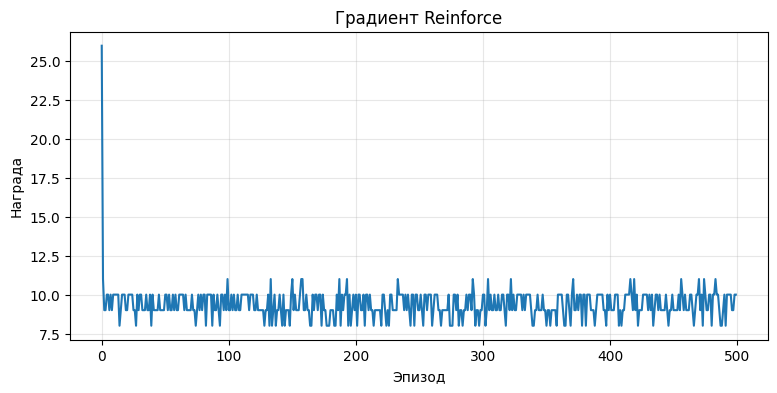

Лучший результат:  500.0
Время работы градиента с параметрами:
 эпизод: 500\скорость:0.03. 177.9895



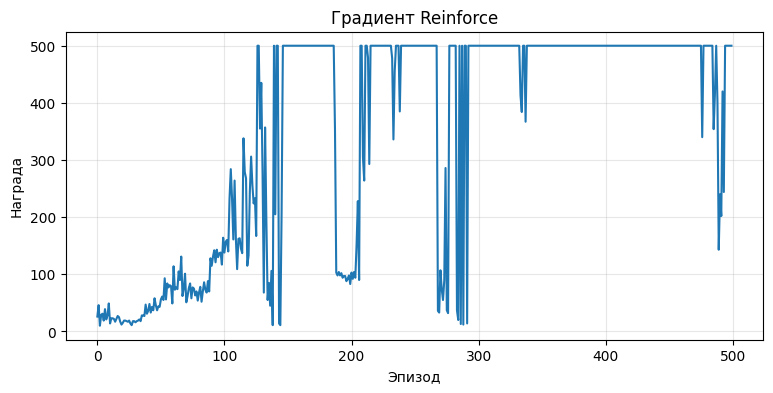

Лучший результат:  500.0
Время работы градиента с параметрами:
 эпизод: 500\скорость:0.003. 86.9531



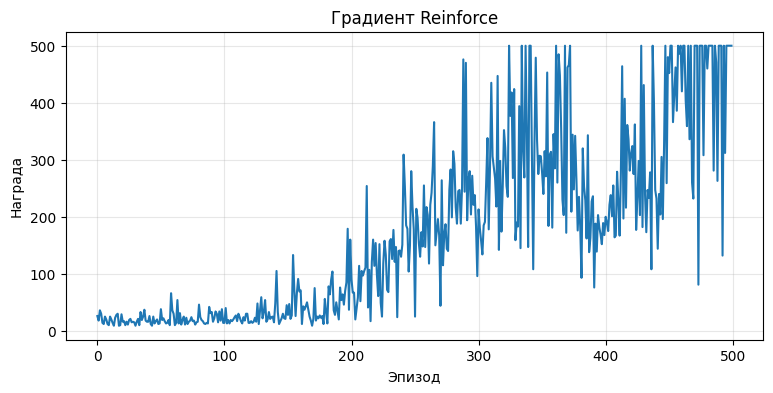

Лучший результат:  26.0
Время работы градиента с параметрами:
 эпизод: 1000\скорость:0.3. 10.9250



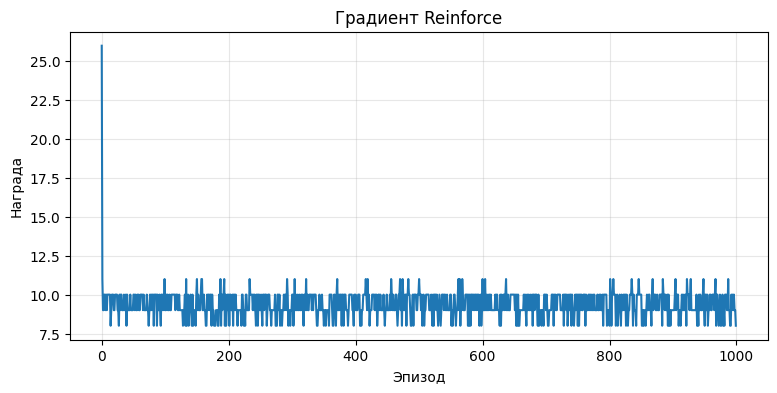

Лучший результат:  500.0
Время работы градиента с параметрами:
 эпизод: 1000\скорость:0.03. 255.3267



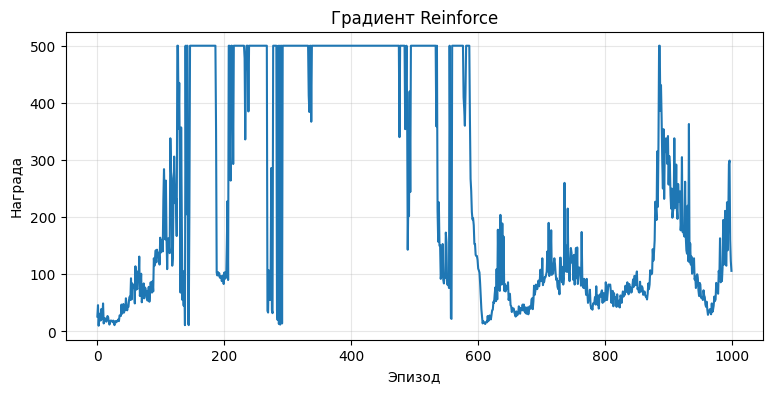

In [37]:
for EPISODES in [100, 300, 500, 1000]:
    for LR in [3e-1, 3e-2, 3e-3]:
        if EPISODES == 1000 and LR == 3e-3:
            continue
        start_time = time.time()
        pg_policy, pg_rewards = train_policy_gradient(env_id="CartPole-v1", episodes=EPISODES, lr=LR, gamma=0.99, seed=42, visible_result=False)
        end_time = time.time()
        print(f"Время работы градиента с параметрами:\n эпизод: {EPISODES}\скорость:{LR}. {end_time - start_time:.4f}\n")
        build_plot(pg_rewards, "Градиент Reinforce")

По таблице и графикам градиента стратегии reinforce, можно сказать, что метод начинает выдавать хороший результат, начиная с 300 эпизодов и скорости обучения в 0.03. При этом, вне зависимости от эпизодов, скорость обучения в 0.3 выдаёт максимально плохой результат в 26 единиц. Таким образом, алгоритм очень чувствителен к скорости обучения. Время обучения самое большое: от 1 до 228 секунд. Нагрыд имеют высокую дисперсию(провалы). При удачном выборе скорости обучения демонстрирует устойчивую сходимость, способен стабильно находить оптимальную политику.
Стабильность:
Случайный поиск демонстрирует крайне низкую стабильность: значения награды имеют большой разброс и не образуют устойчивого тренда. Алгоритм восхождения на вершину после выхода на высокий уровень награды, как правило, удерживает его, что свидетельствует о хорошей временной стабильности при корректно выбранном уровне шума. Метод градиента стратегии показывает способность достигать оптимальной награды, однако характеризуется резкими колебаниями и высокой чувствительностью к скорости обучения, что снижает его стабильность.
Время выполнения:
По времени обучения наименьшие затраты демонстрирует случайный поиск, однако его нестабильность делает данный метод малоэффективным.
Алгоритм восхождения на вершину обеспечивает относительно среднее время обучения и наиболее устойчивое достижение максимальной награды.
Метод градиента стратегии требует наибольшее время обучения и характеризуется высокой чувствительностью к гиперпараметрам, что приводит к снижению стабильности процесса.


В работе были изучены и экспериментально исследованы три алгоритма обучения с подкреплением: случайный поиск, восхождение на вершину и градиент стратегии на средах CartPole и MountainCar.
Показано, что случайный поиск является самым простым и быстрым по времени, однако обладает низкой эффективностью и стабильностью, так как не использует накопленный опыт и приводит к успеху лишь случайно.
Алгоритм восхождения на вершину продемонстрировал наилучший баланс между качеством решения, скоростью обучения и устойчивостью. Он стабильно сходится к хорошей политике и требует сравнительно небольших вычислительных затрат, что делает его практичным для задач с параметризованными политиками.
Метод градиента стратегии способен достигать оптимальных результатов, однако требует значительно большего времени обучения и чувствителен к выбору гиперпараметров. Это снижает его стабильность, несмотря на теоретическую обоснованность и универсальность.
В целом результаты показывают, что для простых задач наиболее целесообразно использовать восхождение на вершину, тогда как градиентные методы более перспективны для сложных задач, а случайный поиск может служить лишь базовым ориентиром.
